In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np

from ucimlrepo import fetch_ucirepo

# fetch dataset 
winequality = fetch_ucirepo(id=186) 

# data (as pandas dataframes) 
X = winequality.data.features 
y = winequality.data.targets 

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [4]:
notebook1 = "real2_WineQuality_1_10000"
notebook2 = "real2_WineQuality_100_100"
notebook3 = "real2_WineQuality_1000_10"
notebook4 = "real2_WineQuality_pt"

In [5]:
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from pathlib import Path
STORE_DIR = Path("store")
notebooks = [notebook1, notebook2, notebook3, notebook4]

def load_method_payload(npz_path, method_key):
    data = np.load(npz_path, allow_pickle=True)
    if method_key in data.files:
        payload = data[method_key]
        return payload.item() if hasattr(payload, "item") else payload

    if method_key == "mtmh" and "default" in data.files:
        default_payload = data["default"]
        default_payload = default_payload.item() if hasattr(default_payload, "item") else default_payload
        default_preds = np.asarray(default_payload["preds"])
        return {"preds": np.full_like(default_preds, np.nan)}

    raise KeyError(f"{method_key} is not a file in the archive")

def get_y_test_subset(y, n_test_points, seed=42):
    _, X_test, _, y_test = train_test_split(X, y, random_state=42)
    rng = np.random.default_rng(seed)
    if n_test_points is not None and n_test_points < X_test.shape[0]:
        idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
    else:
        idx = np.arange(X_test.shape[0])
    return y_test[idx]

In [6]:
def crps_from_samples(samples, y_true):
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def compute_metrics_for_notebook(name):
    npz_path = STORE_DIR / f"{name}.npz"
    default_payload = load_method_payload(npz_path, "default")

    preds_default = default_payload["preds"]  # (n_chains, n_test, ndpost)
    n_test_points = preds_default.shape[1]
    y_test_sub = get_y_test_subset(y, n_test_points=n_test_points, seed=42)

    mean_preds_default = preds_default.mean(axis=(0, 2))
    rmse_default = root_mean_squared_error(y_test_sub, mean_preds_default)
    samples_default = preds_default.transpose(1, 0, 2).reshape(n_test_points, -1)
    crps_default = crps_from_samples(samples_default, y_test_sub).mean()

    mtmh_payload = load_method_payload(npz_path, "mtmh")
    preds_mtmh = np.asarray(mtmh_payload["preds"])

    if np.isfinite(preds_mtmh).any():
        mean_preds_mtmh = preds_mtmh.mean(axis=(0, 2))
        if np.isfinite(mean_preds_mtmh).all():
            rmse_mtmh = root_mean_squared_error(y_test_sub, mean_preds_mtmh)
        else:
            rmse_mtmh = np.nan

        samples_mtmh = preds_mtmh.transpose(1, 0, 2).reshape(n_test_points, -1)
        if np.isfinite(samples_mtmh).any():
            crps_mtmh = crps_from_samples(samples_mtmh, y_test_sub).mean()
        else:
            crps_mtmh = np.nan
    else:
        rmse_mtmh = np.nan
        crps_mtmh = np.nan

    return {
        "notebook": name,
        "rmse_default": rmse_default,
        "rmse_mtmh": rmse_mtmh,
        "crps_default": crps_default,
        "crps_mtmh": crps_mtmh,
    }

metrics = [compute_metrics_for_notebook(name) for name in notebooks]
metrics_df = pd.DataFrame(metrics).set_index("notebook")

rmse_table = metrics_df[["rmse_default", "rmse_mtmh"]].rename(
    columns={"rmse_default": "default", "rmse_mtmh": "mtmh"}
 )
crps_table = metrics_df[["crps_default", "crps_mtmh"]].rename(
    columns={"crps_default": "default", "crps_mtmh": "mtmh"}
 )

print("CRPS table")
display(crps_table)

CRPS table


,default,mtmh
notebook,,
real2_WineQuality_1_10000,0.438540,0.425848
real2_WineQuality_100_100,0.424911,0.417162
real2_WineQuality_1000_10,0.423893,0.419891
real2_WineQuality_pt,0.431281,NaN


Updated RMSE table against y_test_sub


,default,mtmh,tabpfn
notebook,,,
real2_WineQuality_1_10000,0.691463,0.679435,0.576445
real2_WineQuality_100_100,0.684393,0.681975,0.576445
real2_WineQuality_1000_10,0.684391,0.684821,0.576445
real2_WineQuality_pt,0.699596,NaN,0.576445


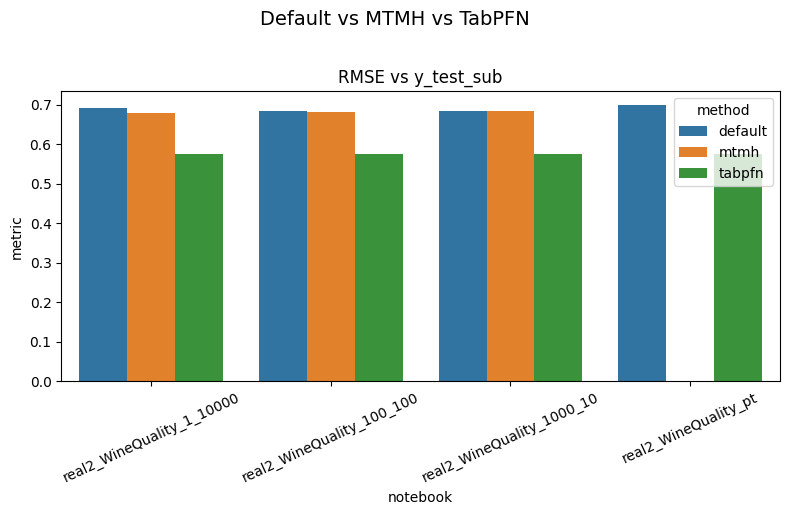

In [7]:
# TabPFN benchmark (regression) on the same train/test split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

try:
    from tabpfn import TabPFNRegressor
except ImportError as e:
    raise ImportError(
        "tabpfn is not installed. Run in a cell: %pip install -U tabpfn"
    ) from e

def get_train_test_subsets_for_benchmark(X, y, n_test_points, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    rng = np.random.default_rng(seed)
    if n_test_points is not None and n_test_points < X_test.shape[0]:
        idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
    else:
        idx = np.arange(X_test.shape[0])

    X_test_sub = X_test[idx]
    y_test_sub = y_test[idx]
    return X_train, y_train, X_test_sub, y_test_sub

def benchmark_tabpfn_regression(notebook_names, seed=42):
    rows = []
    pred_store = {}

    for name in notebook_names:
        npz_path = STORE_DIR / f"{name}.npz"
        default_payload = load_method_payload(npz_path, "default")
        n_test_points = default_payload["preds"].shape[1]

        X_train, y_train, X_test_sub, y_test_sub = get_train_test_subsets_for_benchmark(
            X, y, n_test_points=n_test_points, seed=seed
        )

        model = TabPFNRegressor(random_state=seed, ignore_pretraining_limits=True)
        model.fit(X_train, y_train)
        preds = model.predict(X_test_sub)

        pred_store[name] = {
            "preds": preds,
            "y_test_sub": y_test_sub,
            "n_test": n_test_points,
        }

        rows.append(
            {
                "notebook": name,
                "tabpfn_rmse": root_mean_squared_error(y_test_sub, preds),
                "n_test": n_test_points,
            }
        )

    return pd.DataFrame(rows).set_index("notebook"), pred_store

tabpfn_df, tabpfn_pred_store = benchmark_tabpfn_regression(notebooks, seed=42)

# Directly append TabPFN RMSE to existing summary table.
if "rmse_table" in globals():
    rmse_table = rmse_table.join(
        tabpfn_df[["tabpfn_rmse"]].rename(columns={"tabpfn_rmse": "tabpfn"})
    )
    print("Updated RMSE table against y_test_sub")
    display(rmse_table)

if "rmse_table" in globals():
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    plot_rmse = rmse_table.reset_index().melt(
        id_vars="notebook", var_name="method", value_name="metric"
    )
    sns.barplot(data=plot_rmse, x="notebook", y="metric", hue="method", ax=ax)
    ax.set_title("RMSE vs y_test_sub")
    ax.tick_params(axis="x", rotation=25)

    fig.suptitle("Default vs MTMH vs TabPFN", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Squared error quantiles table


,,n_test,q05,q25,q50,q75,q95
method,notebook,,,,,,
default,real2_WineQuality_1_10000,100,0.001481,0.066460,0.188446,0.489423,1.392692
mtmh,real2_WineQuality_1_10000,100,0.001911,0.063254,0.155730,0.491054,1.633176
default,real2_WineQuality_100_100,100,0.003748,0.056814,0.160290,0.450994,1.489944
mtmh,real2_WineQuality_100_100,100,0.002650,0.048407,0.128466,0.484106,1.685839
default,real2_WineQuality_1000_10,100,0.003220,0.052392,0.145522,0.472892,1.548122
mtmh,real2_WineQuality_1000_10,100,0.001372,0.049737,0.136590,0.477345,1.702627
default,real2_WineQuality_pt,100,0.002686,0.067844,0.154401,0.480764,1.795978
mtmh,real2_WineQuality_pt,100,NaN,NaN,NaN,NaN,NaN
tabpfn,tabpfn,100,0.000593,0.019587,0.081438,0.341223,1.358570


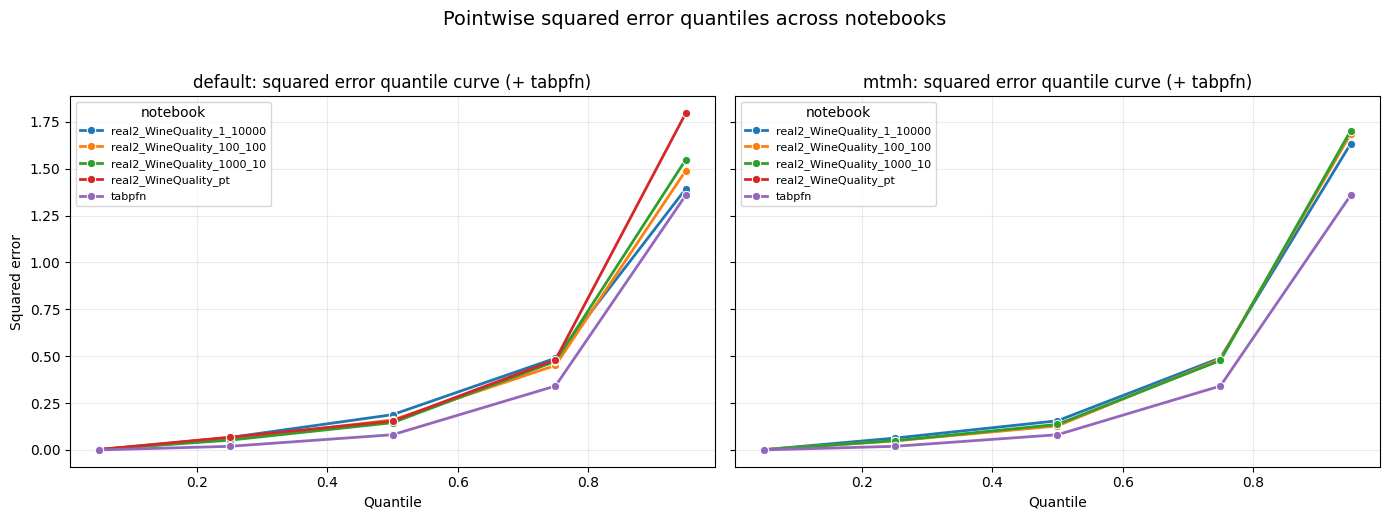

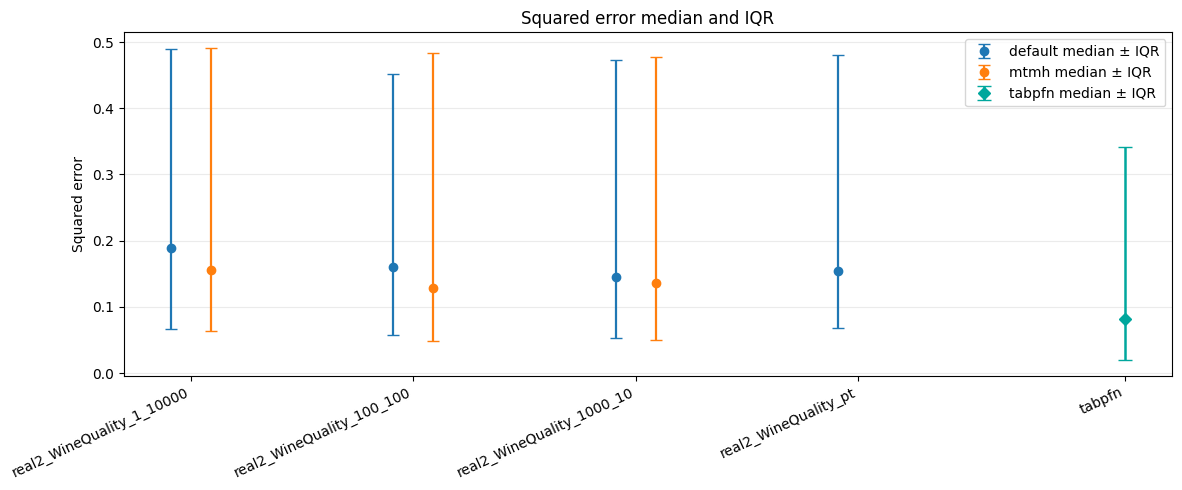

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def squared_error_quantile_diagnostic(notebook_names, quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)):
    methods = ["default", "mtmh"]
    rows = []

    for name in notebook_names:
        npz_path = STORE_DIR / f"{name}.npz"

        for method in methods:
            payload = load_method_payload(npz_path, method)
            preds = payload["preds"]  # (n_chains, n_test, ndpost)
            n_test_points = preds.shape[1]
            y_test_sub = get_y_test_subset(y, n_test_points=n_test_points, seed=42)

            mean_pred = preds.mean(axis=(0, 2))
            sq_err = (mean_pred - y_test_sub) ** 2

            qvals = np.quantile(sq_err, quantiles)
            row = {
                "notebook": name,
                "method": method,
                "n_test": n_test_points,
            }
            row.update({f"q{int(q * 100):02d}": v for q, v in zip(quantiles, qvals)})
            rows.append(row)

    if "tabpfn_pred_store" not in globals():
        raise RuntimeError(
            "tabpfn_pred_store not found. Please run the TabPFN benchmark cell first."
        )

    # Use one cached TabPFN prediction (same split / same n_test), do not aggregate repeatedly.
    tabpfn_key = notebook_names[0]
    if tabpfn_key not in tabpfn_pred_store:
        raise KeyError(f"{tabpfn_key} not found in tabpfn_pred_store")

    preds_tabpfn = tabpfn_pred_store[tabpfn_key]["preds"]
    y_test_sub_tabpfn = tabpfn_pred_store[tabpfn_key]["y_test_sub"]
    n_test_tabpfn = tabpfn_pred_store[tabpfn_key]["n_test"]
    sq_err_tabpfn = (preds_tabpfn - y_test_sub_tabpfn) ** 2
    qvals_tabpfn = np.quantile(sq_err_tabpfn, quantiles)

    tabpfn_row = {
        "notebook": "tabpfn",
        "method": "tabpfn",
        "n_test": int(n_test_tabpfn),
    }
    tabpfn_row.update({f"q{int(q * 100):02d}": v for q, v in zip(quantiles, qvals_tabpfn)})
    rows.append(tabpfn_row)

    df_q = pd.DataFrame(rows)

    print("Squared error quantiles table")
    display(df_q.set_index(["method", "notebook"]))

    # Plot 1: keep original two panels (default / mtmh), and overlay one TabPFN line in each panel.
    q_cols = [f"q{int(q * 100):02d}" for q in quantiles]
    long_df = df_q.melt(
        id_vars=["notebook", "method"],
        value_vars=q_cols,
        var_name="quantile",
        value_name="squared_error",
    )
    q_map = {f"q{int(q * 100):02d}": q for q in quantiles}
    long_df["quantile"] = long_df["quantile"].map(q_map)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, method in zip(axes, methods):
        tmp = long_df[(long_df["method"] == method) | (long_df["method"] == "tabpfn")]
        sns.lineplot(
            data=tmp,
            x="quantile",
            y="squared_error",
            hue="notebook",
            marker="o",
            linewidth=2,
            ax=ax,
        )
        ax.set_title(f"{method}: squared error quantile curve (+ tabpfn)")
        ax.set_xlabel("Quantile")
        ax.set_ylabel("Squared error")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, title="notebook")

    fig.suptitle("Pointwise squared error quantiles across notebooks", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    # Plot 2: median (q50) with IQR (q25-q75) for default/mtmh, plus one TabPFN point.
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(notebook_names))
    width = 0.18

    for j, method in enumerate(["default", "mtmh"]):
        sub = df_q[(df_q["method"] == method) & (df_q["notebook"].isin(notebook_names))]
        sub = sub.set_index("notebook").loc[notebook_names]
        q25 = sub["q25"].values
        q50 = sub["q50"].values
        q75 = sub["q75"].values
        xpos = x + (j - 0.5) * width

        ax.errorbar(
            xpos,
            q50,
            yerr=[q50 - q25, q75 - q50],
            fmt="o",
            capsize=4,
            linewidth=1.6,
            label=f"{method} median ± IQR",
        )

    tabpfn_sub = df_q[(df_q["method"] == "tabpfn") & (df_q["notebook"] == "tabpfn")]
    if len(tabpfn_sub) == 1:
        q25_t = tabpfn_sub["q25"].iloc[0]
        q50_t = tabpfn_sub["q50"].iloc[0]
        q75_t = tabpfn_sub["q75"].iloc[0]
        xpos_t = len(notebook_names) + 0.2
        ax.errorbar(
            [xpos_t],
            [q50_t],
            yerr=[[q50_t - q25_t], [q75_t - q50_t]],
            fmt="D",
            capsize=5,
            linewidth=1.8,
            color="#00A79D",
            label="tabpfn median ± IQR",
        )

    ax.set_xticks(np.append(x, len(notebook_names) + 0.2))
    ax.set_xticklabels(list(notebook_names) + ["tabpfn"], rotation=25, ha="right")
    ax.set_ylabel("Squared error")
    ax.set_title("Squared error median and IQR")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df_q

se_quantiles_df = squared_error_quantile_diagnostic(notebooks)

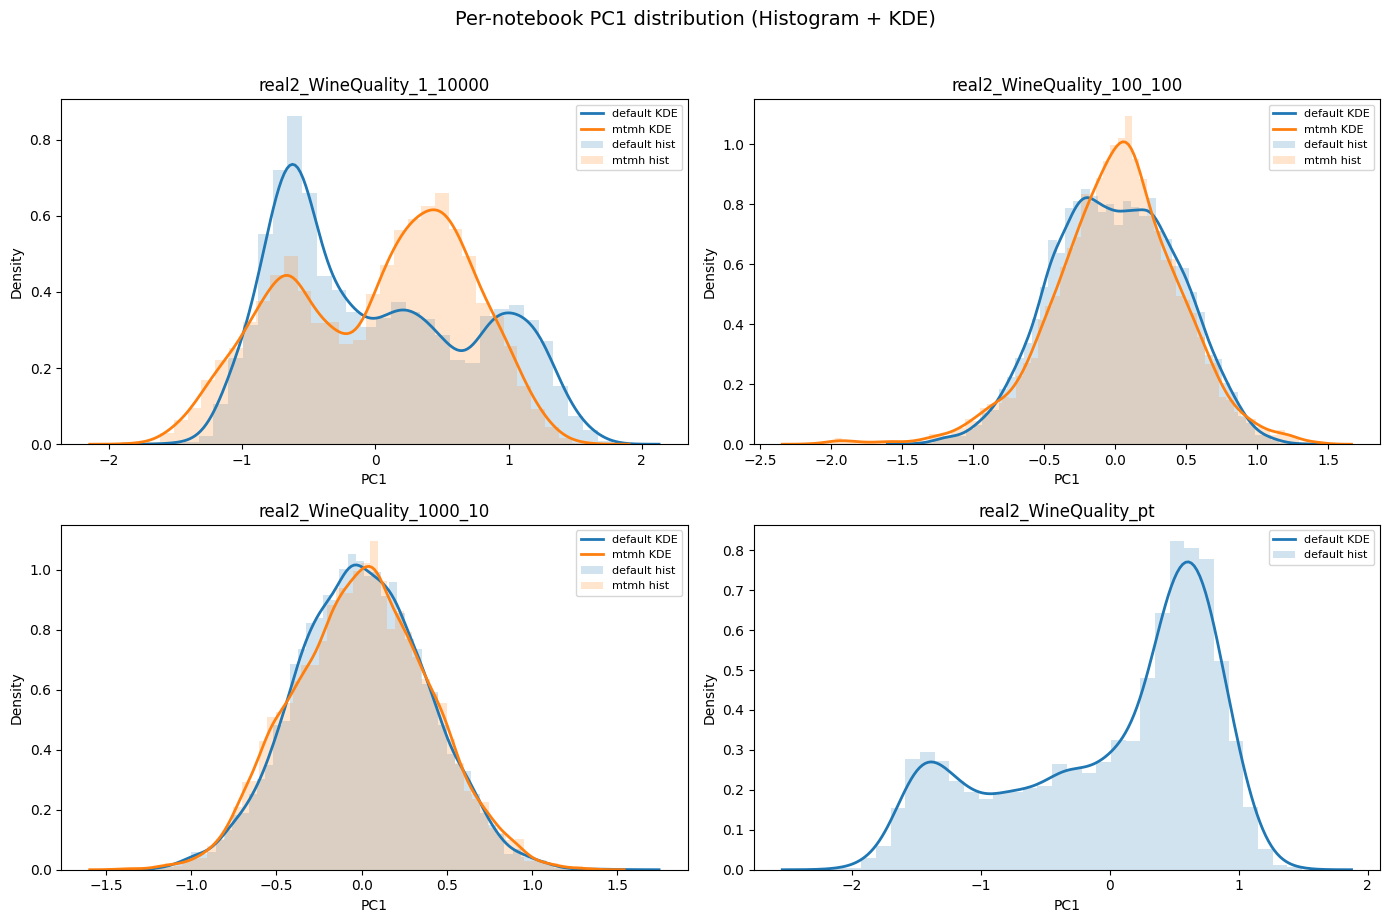

In [9]:
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_pc1(preds):
    arr = np.asarray(preds)
    if not np.isfinite(arr).any():
        return None
    mat = arr.transpose(0, 2, 1).reshape(-1, arr.shape[1])
    if not np.isfinite(mat).all():
        return None
    return PCA(n_components=1).fit_transform(mat)[:, 0]

n = len(notebooks)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, name in enumerate(notebooks):
    npz_path = STORE_DIR / f"{name}.npz"
    default_payload = load_method_payload(npz_path, "default")
    mtmh_payload = load_method_payload(npz_path, "mtmh")

    pc1_default = preds_to_pc1(default_payload["preds"])
    pc1_mtmh = preds_to_pc1(mtmh_payload["preds"])

    ax = axes[i]
    if pc1_default is not None:
        sns.histplot(
            pc1_default,
            bins="auto",
            stat="density",
            alpha=0.20,
            color="#1f77b4",
            edgecolor=None,
            ax=ax,
            label="default hist",
        )
        sns.kdeplot(pc1_default, color="#1f77b4", linewidth=2, ax=ax, label="default KDE")

    if pc1_mtmh is not None:
        sns.histplot(
            pc1_mtmh,
            bins="auto",
            stat="density",
            alpha=0.20,
            color="#ff7f0e",
            edgecolor=None,
            ax=ax,
            label="mtmh hist",
        )
        sns.kdeplot(pc1_mtmh, color="#ff7f0e", linewidth=2, ax=ax, label="mtmh KDE")

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-notebook PC1 distribution (Histogram + KDE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

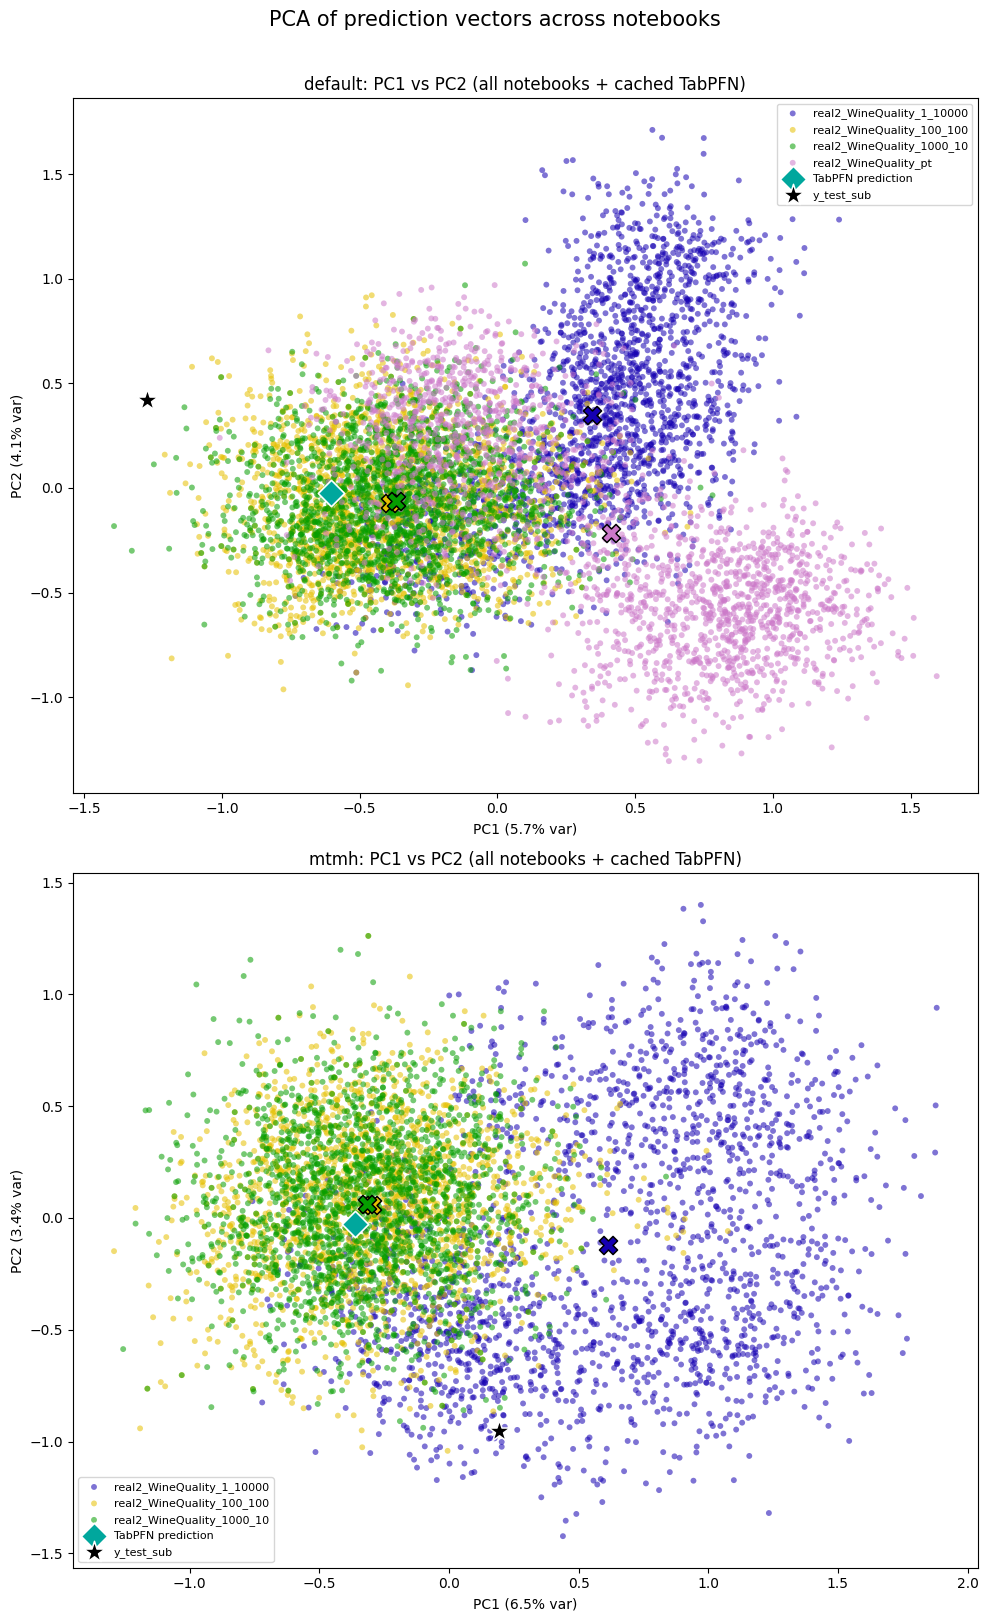

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_matrix(npz_path, method_key):
    payload = load_method_payload(npz_path, method_key)
    preds = np.asarray(payload["preds"])  # (n_chains, n_test, ndpost)
    if not np.isfinite(preds).any():
        return None
    n_chains, n_test, ndpost = preds.shape
    mat = preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)
    if not np.isfinite(mat).all():
        return None
    return mat

def get_distinct_colors(n):
    base_colors = ["#1500B2", "#E6C000", "#059E00", "#CC79C9", "#D50000"]
    if n <= len(base_colors):
        return base_colors[:n]
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(n)]

def get_cached_tabpfn_reference(notebook_names, n_test_points):
    if "tabpfn_pred_store" not in globals():
        raise RuntimeError(
            "tabpfn_pred_store not found. Please run the TabPFN benchmark cell first."
        )

    for name in notebook_names:
        if name in tabpfn_pred_store and tabpfn_pred_store[name]["n_test"] == n_test_points:
            return tabpfn_pred_store[name]

    raise ValueError(
        f"No cached TabPFN prediction matches n_test={n_test_points}. "
        "Please rerun the TabPFN benchmark cell to refresh cache."
    )

def plot_notebooks_pca_panels(notebook_names, plot_step=5, mark_centroid=True):
    methods = ["default", "mtmh"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 16))
    colors = get_distinct_colors(len(notebook_names))

    for ax, method_key in zip(axes, methods):
        mats = []
        labels = []

        for name in notebook_names:
            npz_path = STORE_DIR / f"{name}.npz"
            mat = preds_to_matrix(npz_path, method_key)
            if mat is not None:
                mats.append(mat)
                labels.append(name)

        if not mats:
            ax.set_title(f"{method_key}: no finite predictions available")
            ax.set_axis_off()
            continue

        X_all = np.vstack(mats)
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_all)

        n_test_points = mats[0].shape[1]
        cached_ref = get_cached_tabpfn_reference(notebook_names, n_test_points=n_test_points)
        y_test_sub = cached_ref["y_test_sub"]
        tabpfn_pred = cached_ref["preds"]

        y_proj = pca.transform(y_test_sub.reshape(1, -1))[0]
        tabpfn_proj = pca.transform(tabpfn_pred.reshape(1, -1))[0]

        start = 0
        for i, (mat, label) in enumerate(zip(mats, labels)):
            n_samples = mat.shape[0]
            segment = pcs[start:start + n_samples]
            idx = np.arange(0, n_samples, plot_step)

            ax.scatter(
                segment[idx, 0],
                segment[idx, 1],
                s=18,
                alpha=0.55,
                label=label,
                c=[colors[i % len(colors)]],
                edgecolors="none",
            )

            if mark_centroid:
                centroid = segment.mean(axis=0)
                ax.scatter(
                    centroid[0],
                    centroid[1],
                    s=170,
                    c=[colors[i % len(colors)]],
                    marker="X",
                    edgecolors="black",
                    linewidths=1.1,
                    zorder=5,
                )

            start += n_samples

        ax.scatter(
            tabpfn_proj[0],
            tabpfn_proj[1],
            s=180,
            c="#00A79D",
            marker="D",
            edgecolors="white",
            linewidths=1.2,
            zorder=7,
            label="TabPFN prediction",
        )

        ax.scatter(
            y_proj[0],
            y_proj[1],
            s=260,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.1,
            zorder=7,
            label="y_test_sub",
        )

        evr = pca.explained_variance_ratio_
        ax.set_xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
        ax.set_ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
        ax.set_title(f"{method_key}: PC1 vs PC2 (all notebooks + cached TabPFN)")
        ax.legend(loc="best", fontsize=8)

    fig.suptitle("PCA of prediction vectors across notebooks", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

plot_notebooks_pca_panels(notebooks, plot_step=5, mark_centroid=True)